
# Realized Volatility Proxies from `yfinance` (Daily OHLCV)

This notebook downloads daily OHLCV data using **`yfinance`** and computes several **realized-volatility proxies** per asset:

- **Parkinson (1980)** high–low estimator  
- **Garman–Klass (1980)** OHLC estimator  
- **Rogers–Satchell (1991)** OHLC estimator robust to drift  
- **Close-to-Close** (squared log-return) baseline

It then aggregates to **1, 5, 22 trading-day** horizons (daily rolling sum of variances), with optional **annualization**. Finally, it exports a long/tidy CSV suitable for modeling pipelines.


In [1]:

# If running locally, uncomment the next line to install yfinance
!pip install yfinance pandas numpy matplotlib


In [2]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from typing import List, Dict


## Parameters

In [3]:

# --- Parameters ---
TICKERS: List[str] = ["SPY", "TLT", "GLD", "QQQ"]   # ETFs for equity, bonds, gold
START_DATE: str = "2010-01-01"
END_DATE: str = None   # None means up to today per yfinance
INTERVAL: str = "1d"   # daily
OUT_CSV_PATH: str = "realized_vol_proxies.csv"

# Aggregation horizons (in trading days) and annualization
HORIZONS: List[int] = [1, 5, 22]
ANNUALIZE: bool = True
TRADING_DAYS_PER_YEAR: int = 252


## Data download

In [1]:

def fetch_ohlcv_yf(tickers: List[str], start: str, end: str = None, interval: str = "1d") -> pd.DataFrame:
    
    data = yf.download(tickers, start=start, end=end, interval=interval, auto_adjust=False, progress=False, group_by='ticker')
    if isinstance(data.columns, pd.MultiIndex):
        frames = []
        for tk in tickers:
            df = data[tk].copy()
            df.columns = [c.lower().replace(" ", "_") for c in df.columns]
            df = df.rename(columns={"adj close": "adj_close"})
            df["ticker"] = tk
            frames.append(df.reset_index().rename(columns={"Date":"date"}))
        out = pd.concat(frames, axis=0, ignore_index=True)
    else:
        # Single-ticker shape
        df = data.copy()
        df.columns = [c.lower().replace(" ", "_") for c in df.columns]
        df = df.rename(columns={"adj close": "adj_close"})
        df["ticker"] = tickers[0]
        out = df.reset_index().rename(columns={"Date":"date"})
    # Clean / enforce dtypes
    out = out.rename(columns={"open":"open", "high":"high", "low":"low", "close":"close", "adj_close":"adj_close", "volume":"volume"})
    out = out.sort_values(["ticker","date"]).reset_index(drop=True)
    return out


NameError: name 'List' is not defined

## Realized-volatility proxies

In [5]:

def compute_rv_proxies(df: pd.DataFrame, horizons: List[int], annualize: bool = True, trading_days: int = 252) -> pd.DataFrame:

    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["ticker", "date"])
    
    # Basic log terms
    df["log_h_l"] = np.log(df["high"] / df["low"])
    df["log_c_o"] = np.log(df["close"] / df["open"])
    df["log_c_prev"] = df.groupby("ticker")["close"].shift(1)
    df["log_ret"] = np.log(df["close"] / df["log_c_prev"])
    
    # Close-to-close daily variance proxy (squared log return)
    df["var_cc"] = df["log_ret"]**2
    
    # Parkinson variance (uses high/low)
    # var = (1 / (4 * ln(2))) * (ln(H/L))^2
    df["var_parkinson"] = (1.0 / (4.0 * math.log(2.0))) * (df["log_h_l"] ** 2)
    
    # Garman–Klass variance (uses high, low, open, close)
    # var = 0.5*(ln(H/L))^2 - (2*ln(2)-1)*(ln(C/O))^2
    df["var_gk"] = 0.5 * (df["log_h_l"] ** 2) - (2.0 * math.log(2.0) - 1.0) * (df["log_c_o"] ** 2)
    
    # Rogers–Satchell variance (robust to drift)
    # var = ln(H/C)*ln(H/O) + ln(L/C)*ln(L/O)
    df["log_h_c"] = np.log(df["high"] / df["close"])
    df["log_h_o"] = np.log(df["high"] / df["open"])
    df["log_l_c"] = np.log(df["low"] / df["close"])
    df["log_l_o"] = np.log(df["low"] / df["open"])
    df["var_rs"] = df["log_h_c"] * df["log_h_o"] + df["log_l_c"] * df["log_l_o"]
    
    # Clip negative GK/RS variances (can happen numerically) at small epsilon
    eps = 1e-12
    for col in ["var_gk", "var_rs"]:
        df[col] = df[col].clip(lower=eps)
    
    # Daily vols (non-annualized, per-day sigma)
    df["vol_cc"] = np.sqrt(df["var_cc"])
    df["vol_parkinson"] = np.sqrt(df["var_parkinson"])
    df["vol_gk"] = np.sqrt(df["var_gk"])
    df["vol_rs"] = np.sqrt(df["var_rs"])
    
    # Aggregate to horizons: sum variances over rolling window, then sqrt
    def agg_horizon(var_col: str, H: int, out_name: str) -> None:
        rolled = df.groupby("ticker")[var_col].rolling(H, min_periods=H).sum().reset_index(level=0, drop=True)
        df[out_name] = np.sqrt(rolled)
    
    for H in horizons:
        agg_horizon("var_cc", H, f"vol_cc_{H}d")
        agg_horizon("var_parkinson", H, f"vol_parkinson_{H}d")
        agg_horizon("var_gk", H, f"vol_gk_{H}d")
        agg_horizon("var_rs", H, f"vol_rs_{H}d")
    
    # Optional annualization (multiply daily sigma by sqrt(252); H-day sigma by sqrt(252/H))
    if annualize:
        df["vol_cc_ann"] = df["vol_cc"] * math.sqrt(trading_days)
        df["vol_parkinson_ann"] = df["vol_parkinson"] * math.sqrt(trading_days)
        df["vol_gk_ann"] = df["vol_gk"] * math.sqrt(trading_days)
        df["vol_rs_ann"] = df["vol_rs"] * math.sqrt(trading_days)
        for H in horizons:
            scale = math.sqrt(trading_days / H)
            df[f"vol_cc_{H}d_ann"] = df[f"vol_cc_{H}d"] * scale
            df[f"vol_parkinson_{H}d_ann"] = df[f"vol_parkinson_{H}d"] * scale
            df[f"vol_gk_{H}d_ann"] = df[f"vol_gk_{H}d"] * scale
            df[f"vol_rs_{H}d_ann"] = df[f"vol_rs_{H}d"] * scale
    
    # Housekeeping
    keep_cols = [
        "date","ticker","open","high","low","close","adj_close","volume",
        "log_ret",
        "var_cc","var_parkinson","var_gk","var_rs",
        "vol_cc","vol_parkinson","vol_gk","vol_rs"
    ]
    if annualize:
        keep_cols += ["vol_cc_ann","vol_parkinson_ann","vol_gk_ann","vol_rs_ann"]
    for H in horizons:
        keep_cols += [f"vol_cc_{H}d", f"vol_parkinson_{H}d", f"vol_gk_{H}d", f"vol_rs_{H}d"]
        if annualize:
            keep_cols += [f"vol_cc_{H}d_ann", f"vol_parkinson_{H}d_ann", f"vol_gk_{H}d_ann", f"vol_rs_{H}d_ann"]
    
    out = df[keep_cols].copy()
    return out


## Run pipeline

In [6]:

# 1) Download OHLCV
ohlcv = fetch_ohlcv_yf(TICKERS, START_DATE, END_DATE, INTERVAL)

# 2) Compute proxies & aggregates
rv = compute_rv_proxies(ohlcv, horizons=HORIZONS, annualize=ANNUALIZE, trading_days=TRADING_DAYS_PER_YEAR)

# 3) Save to CSV
rv.to_csv(OUT_CSV_PATH, index=False)
print(f"Saved: {OUT_CSV_PATH}\nRows: {len(rv):,}")
rv.head()


Saved: realized_vol_proxies.csv
Rows: 15,972


,date,ticker,open,high,low,close,adj_close,volume,log_ret,var_cc,...,vol_gk_5d_ann,vol_rs_5d_ann,vol_cc_22d,vol_parkinson_22d,vol_gk_22d,vol_rs_22d,vol_cc_22d_ann,vol_parkinson_22d_ann,vol_gk_22d_ann,vol_rs_22d_ann
0,2010-01-04,GLD,109.820000,110.139999,109.309998,109.800003,109.800003,16224100,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-05,GLD,109.879997,110.389999,109.260002,109.699997,109.699997,14213100,-0.000911,8.303172e-07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-06,GLD,110.709999,111.769997,110.410004,111.510002,111.510002,24981900,0.016365,2.678117e-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-07,GLD,111.070000,111.290001,110.620003,110.820000,110.820000,13609800,-0.006207,3.852724e-05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-08,GLD,111.519997,111.580002,110.260002,111.370003,111.370003,15894600,0.004951,2.450998e-05,...,0.105726,0.114741,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Quick plots

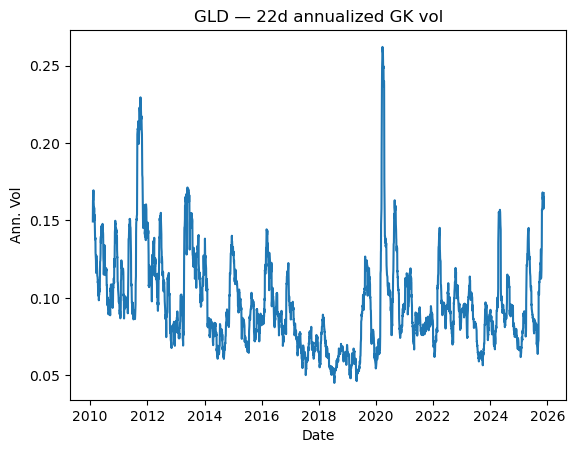

In [7]:

# Plot an example: 22-day annualized Garman–Klass volatility for the first ticker
example_tk = rv['ticker'].iloc[0]
sub = rv[rv['ticker'] == example_tk].dropna(subset=['vol_gk_22d_ann'])

plt.figure()
plt.plot(sub['date'], sub['vol_gk_22d_ann'])
plt.title(f"{example_tk} — 22d annualized GK vol")
plt.xlabel("Date")
plt.ylabel("Ann. Vol")
plt.show()



### Notes & Caveats
- These are **proxies** for realized volatility using daily OHLCV; they correlate well with true realized vol from high-frequency data, but are not identical.
- **Rogers–Satchell** and **Garman–Klass** can occasionally produce tiny negative values due to numerical issues; we clip at a small epsilon before taking square roots.
- For **intraday (5-minute) realized variance**, use data vendors providing minute bars or trades, then sum squared intraday log returns per day.
- The **annualization** scales daily sigma by \(\sqrt{252}\), and H-day sigma by \(\sqrt{252/H}\).
- CSV output is in long format and ready to merge with other features (VIX, calendars, etc.).
